In [64]:
import numpy as np
from sklearn import preprocessing


import pandas

#loading data
data = pandas.read_csv("NewFinalSheet2.csv")

#converting data types to correct forms
data['IPOrig'] = data['IPOrig'].astype(str)
data['PortOrig'] = data['PortOrig'].astype(int)
data['IPResp'] = data['IPResp'].astype(str)
data['PortResp'] = data['PortResp'].astype(int)
data['proto'] = data['proto'].astype(str)
data['service'] = data['service'].astype(str)
data['conn_state'] = data['conn_state'].astype(str)
data['duration'] = data['duration'].astype(float)
data['orig_bytes'] = data['orig_bytes'].astype(int)
data['resp_bytes'] = data['resp_bytes'].astype(int)
data['missed_bytes'] = data['missed_bytes'].astype(int)
data['history'] = data['history'].astype(str)
data['orig_pkts'] = data['orig_pkts'].astype(int)
data['orig_ip_bytes'] = data['orig_ip_bytes'].astype(int)
data['resp_pkts'] = data['resp_pkts'].astype(int)
data['resp_ip_bytes'] = data['orig_ip_bytes'].astype(int)
data['label'] = data['label'].astype(str)

#creating 2 arrays for storing IP address for later processing 
newa = np.array(data['IPOrig']).reshape(data.shape[0])
newa2 = np.array(data['IPResp']).reshape(data.shape[0])


#viewing data 
data.head()


,IPOrig,PortOrig,IPResp,PortResp,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label
0,192.168.1.193,50174,134.209.72.171,4554,tcp,-,3.104722,0,0,S0,0,S,6,360,0,360,Malicious C&C
1,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000006,0,0,S0,0,S,2,120,0,120,Malicious C&C
2,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000005,0,0,S0,0,S,2,120,0,120,Malicious C&C
3,192.168.1.193,50196,134.209.72.171,4554,tcp,-,1.262268,11,11,SF,0,ShADdfrFr,12,678,10,678,Malicious C&C
4,192.168.1.193,50198,134.209.72.171,4554,tcp,-,0.211868,11,11,SF,0,ShADdfrFr,10,558,10,558,Malicious C&C


In [65]:
print("Shape of the data is: ", data.shape)
print("The Types of data are:\n",data.dtypes)


Shape of the data is:  (23609, 17)
The Types of data are:
 IPOrig            object
PortOrig           int32
IPResp            object
PortResp           int32
proto             object
service           object
duration         float64
orig_bytes         int32
resp_bytes         int32
conn_state        object
missed_bytes       int32
history           object
orig_pkts          int32
orig_ip_bytes      int32
resp_pkts          int32
resp_ip_bytes      int32
label             object
dtype: object


In [66]:
print("Objects in dataset are:")
ObjData = data.select_dtypes(include=[object])
ObjData.head()

Objects in dataset are:


,IPOrig,IPResp,proto,service,conn_state,history,label
0,192.168.1.193,134.209.72.171,tcp,-,S0,S,Malicious C&C
1,192.168.1.193,134.209.72.171,tcp,-,S0,S,Malicious C&C
2,192.168.1.193,134.209.72.171,tcp,-,S0,S,Malicious C&C
3,192.168.1.193,134.209.72.171,tcp,-,SF,ShADdfrFr,Malicious C&C
4,192.168.1.193,134.209.72.171,tcp,-,SF,ShADdfrFr,Malicious C&C


In [67]:
print("The number of unique values for each column is  ")
print(data.nunique())
#data.dropna()
#data.isnull().sum().shape


The number of unique values for each column is  
IPOrig              20
PortOrig         12276
IPResp            7051
PortResp            18
proto                2
service              7
duration         15052
orig_bytes        6947
resp_bytes         144
conn_state          10
missed_bytes         3
history             70
orig_pkts          132
orig_ip_bytes      379
resp_pkts           56
resp_ip_bytes      379
label                4
dtype: int64


In [68]:
#In order to Use the IP address the values cannot be used as string and have to converted to numbers 
#this step is for IPOrig 

list1 = newa.tolist()
arr1 = np.array([])
arr2 = np.array([])
arr3 = np.array([])
arr4 = np.array([])

#loop over all IP stored in the list and convert it from string to binary to decimal 
for pnt in range(len(list1)):
    x = list1[pnt]
    if(x != 'nan'):
        z = 0
        parts = x.split('.')
        arr1 = np.append(arr1, parts[0])
        arr2 = np.append(arr2, parts[1])
        arr3 = np.append(arr3, parts[2])
        arr4 = np.append(arr4, parts[3])

        z = (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    list1[pnt]= z
    
#Append the generated decimal IPs to a new column in dataset 
newar = np.array(list1)

data['newIP1'] = newar
data

,IPOrig,PortOrig,IPResp,PortResp,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,newIP1
0,192.168.1.193,50174,134.209.72.171,4554,tcp,-,3.104722,0,0,S0,0,S,6,360,0,360,Malicious C&C,3232235969
1,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000006,0,0,S0,0,S,2,120,0,120,Malicious C&C,3232235969
2,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000005,0,0,S0,0,S,2,120,0,120,Malicious C&C,3232235969
3,192.168.1.193,50196,134.209.72.171,4554,tcp,-,1.262268,11,11,SF,0,ShADdfrFr,12,678,10,678,Malicious C&C,3232235969
4,192.168.1.193,50198,134.209.72.171,4554,tcp,-,0.211868,11,11,SF,0,ShADdfrFr,10,558,10,558,Malicious C&C,3232235969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23604,192.168.1.196,33668,209.97.190.136,22,tcp,-,95.937723,773044212,0,OTH,0,DTT,58,2900,0,2900,Malicious DDoS,3232235972
23605,192.168.1.196,35513,209.97.190.136,22,tcp,-,96.609083,1553609407,0,OTH,0,DTT,68,3400,0,3400,Malicious DDoS,3232235972
23606,192.168.1.196,55840,209.97.190.136,22,tcp,-,95.699321,-376893875,0,OTH,0,DTT,64,3200,0,3200,Malicious DDoS,3232235972
23607,192.168.1.196,62777,209.97.190.136,22,tcp,-,96.345271,1464233671,0,OTH,0,DTT,61,3050,0,3050,Malicious DDoS,3232235972


In [69]:
#In order to Use the IP address the values cannot be used as string and have to converted to numbers 
#this step is for IPResp

list2 = newa2.tolist()
arr11 = np.array([])
arr22 = np.array([])
arr33 = np.array([])
arr44 = np.array([])

for pnt in range(len(list2)):
    m = list2[pnt]
    if(m != 'nan'):
        z = 0
        parts2 = m.split('.')
        arr11 = np.append(arr11, parts2[0])
        arr22 = np.append(arr22, parts2[1])
        arr33 = np.append(arr33, parts2[2])
        arr44 = np.append(arr44, parts2[3])

        z = (int(parts2[0]) << 24) + (int(parts2[1]) << 16) + (int(parts2[2]) << 8) + int(parts2[3])
    list2[pnt]= z

newar2 = np.array(list2)

data['newIP2'] = newar2
data


,IPOrig,PortOrig,IPResp,PortResp,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,newIP1,newIP2
0,192.168.1.193,50174,134.209.72.171,4554,tcp,-,3.104722,0,0,S0,0,S,6,360,0,360,Malicious C&C,3232235969,2261862571
1,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000006,0,0,S0,0,S,2,120,0,120,Malicious C&C,3232235969,2261862571
2,192.168.1.193,50174,134.209.72.171,4554,tcp,-,0.000005,0,0,S0,0,S,2,120,0,120,Malicious C&C,3232235969,2261862571
3,192.168.1.193,50196,134.209.72.171,4554,tcp,-,1.262268,11,11,SF,0,ShADdfrFr,12,678,10,678,Malicious C&C,3232235969,2261862571
4,192.168.1.193,50198,134.209.72.171,4554,tcp,-,0.211868,11,11,SF,0,ShADdfrFr,10,558,10,558,Malicious C&C,3232235969,2261862571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23604,192.168.1.196,33668,209.97.190.136,22,tcp,-,95.937723,773044212,0,OTH,0,DTT,58,2900,0,2900,Malicious DDoS,3232235972,3512843912
23605,192.168.1.196,35513,209.97.190.136,22,tcp,-,96.609083,1553609407,0,OTH,0,DTT,68,3400,0,3400,Malicious DDoS,3232235972,3512843912
23606,192.168.1.196,55840,209.97.190.136,22,tcp,-,95.699321,-376893875,0,OTH,0,DTT,64,3200,0,3200,Malicious DDoS,3232235972,3512843912
23607,192.168.1.196,62777,209.97.190.136,22,tcp,-,96.345271,1464233671,0,OTH,0,DTT,61,3050,0,3050,Malicious DDoS,3232235972,3512843912


In [70]:
# this step is for label encoding the data in order to use the object types of the dataset 

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
labelencoder_X = LabelEncoder()

X = data.iloc[:,:].values

X[:, 16] = labelencoder_X.fit_transform(X[:, 16])
X[:, 4] = labelencoder_X.fit_transform(X[:, 4])
X[:, 5] = labelencoder_X.fit_transform(X[:, 5])
X[:, 9] = labelencoder_X.fit_transform(X[:, 9])
X[:, 11] = labelencoder_X.fit_transform(X[:, 11])


In [71]:
Y = pandas.DataFrame(X)
print(Y)

                  0      1               2     3  4  5         6           7   \
0      192.168.1.193  50174  134.209.72.171  4554  0  0   3.10472           0   
1      192.168.1.193  50174  134.209.72.171  4554  0  0     6e-06           0   
2      192.168.1.193  50174  134.209.72.171  4554  0  0     5e-06           0   
3      192.168.1.193  50196  134.209.72.171  4554  0  0   1.26227          11   
4      192.168.1.193  50198  134.209.72.171  4554  0  0  0.211868          11   
...              ...    ...             ...   ... .. ..       ...         ...   
23604  192.168.1.196  33668  209.97.190.136    22  0  0   95.9377   773044212   
23605  192.168.1.196  35513  209.97.190.136    22  0  0   96.6091  1553609407   
23606  192.168.1.196  55840  209.97.190.136    22  0  0   95.6993  -376893875   
23607  192.168.1.196  62777  209.97.190.136    22  0  0   96.3453  1464233671   
23608  192.168.1.196   2548  209.97.190.136    22  0  0   96.6333  -620022642   

       8  9  10  11  12    

In [72]:
Y.dtypes

0     object
1     object
2     object
3     object
4     object
5     object
6     object
7     object
8     object
9     object
10    object
11    object
12    object
13    object
14    object
15    object
16    object
17    object
18    object
dtype: object

In [73]:
#converting back the datatypes of the dataframe for the model to process correctly 
Y[0] = Y[0].astype(str)
Y[1] = Y[1].astype(int)
Y[2] = Y[2].astype(str)
Y[3] = Y[3].astype(int)
Y[4] = Y[4].astype(str)
Y[5] = Y[5].astype(str)
Y[6] = Y[6].astype(float)
Y[7] = Y[7].astype(int)
Y[8] = Y[8].astype(int)
Y[9] = Y[9].astype(str)
Y[10] = Y[10].astype(int)
Y[11] = Y[11].astype(str)
Y[12] = Y[12].astype(int)
Y[13] = Y[13].astype(int)
Y[14] = Y[14].astype(int)
Y[15] = Y[15].astype(int)
Y[16] = Y[16].astype(str)
Y[17] = Y[17].astype(float)
Y[18] = Y[18].astype(float)



In [74]:
Y.dtypes

0      object
1       int32
2      object
3       int32
4      object
5      object
6     float64
7       int32
8       int32
9      object
10      int32
11     object
12      int32
13      int32
14      int32
15      int32
16     object
17    float64
18    float64
dtype: object

In [75]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.feature_selection import SelectKBest, chi2 
clf1 = tree.DecisionTreeClassifier()
#print()
y= Y[[16]].iloc[:,-1]
x= Y.drop([16,0,2],axis=1)
print(x)


#creating a list that contains the names of the used features 
featureCols = data.columns.values.tolist()
featureCols.remove('IPOrig')
featureCols.remove('PortResp')
featureCols.remove('label')



          1     3  4  5          6           7   8  9   10  11  12    13  14  \
0      50174  4554  0  0   3.104722           0   0  5   0  12   6   360   0   
1      50174  4554  0  0   0.000006           0   0  5   0  12   2   120   0   
2      50174  4554  0  0   0.000005           0   0  5   0  12   2   120   0   
3      50196  4554  0  0   1.262268          11  11  8   0  47  12   678  10   
4      50198  4554  0  0   0.211868          11  11  8   0  47  10   558  10   
...      ...   ... .. ..        ...         ...  .. ..  ..  ..  ..   ...  ..   
23604  33668    22  0  0  95.937723   773044212   0  0   0   3  58  2900   0   
23605  35513    22  0  0  96.609083  1553609407   0  0   0   3  68  3400   0   
23606  55840    22  0  0  95.699321  -376893875   0  0   0   3  64  3200   0   
23607  62777    22  0  0  96.345271  1464233671   0  0   0   3  61  3050   0   
23608   2548    22  0  0  96.633344  -620022642   0  0   0   3  56  2800   0   

         15            17            18

<h2>Feature Selction<h2>

<AxesSubplot:>

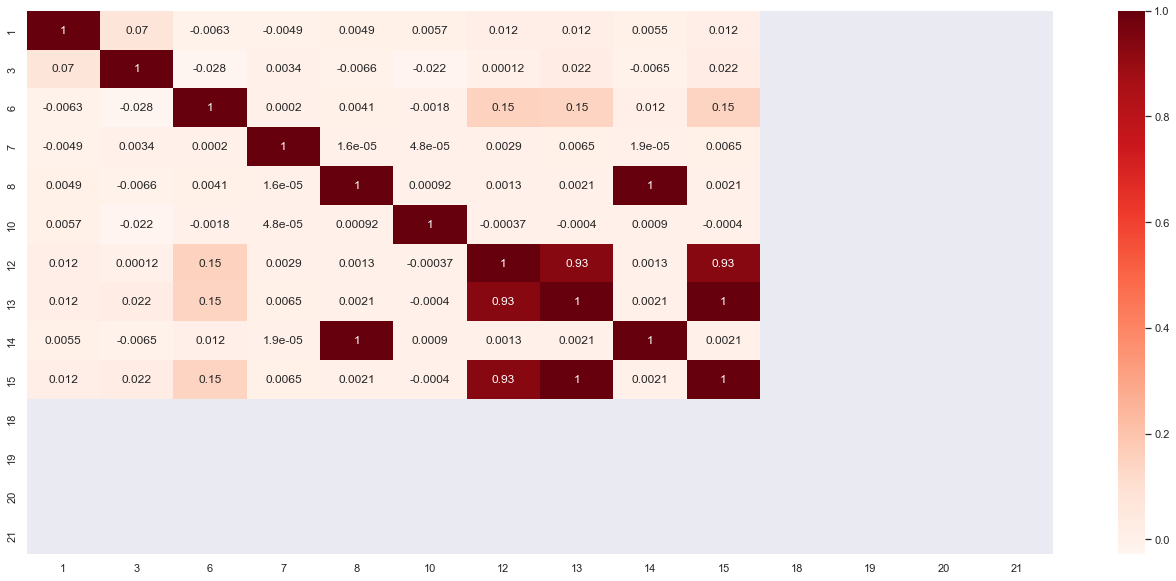

In [ ]:
#Using Pearson Correlation
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set(rc = {'figure.figsize':(16,12)})

plt.figure(figsize=(23,10))
#f, ax = plt.subplots(figsize=(16, 12))
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)


#plt.show()



<h1>Functions and Model Training</h1>

In [76]:
from sklearn.model_selection import KFold 
from sklearn.metrics import accuracy_score

#function for k fold 
k = 10
kf = KFold(n_splits=k, random_state=True, shuffle=True)

clf=[]
training_accuracy=[]
testing_accuracy=[]
nodes=[]

sum_training=0
sum_testing=0
sum_nodes=0

acc_score = []

#function for training of model on each fold 
def modelTrainKfold(x,y, model, type1): 
    clf=[]
    training_accuracy=[]
    testing_accuracy=[]
    nodes=[]

    sum_training=0
    sum_testing=0
    sum_nodes=0

    acc_score = []
    for train_index , test_index in kf.split(x):
        fold = 1
        X_train , X_test = x.iloc[train_index,:],x.iloc[test_index,:]
        y_train , y_test = y[train_index] , y[test_index]

        model.fit(X_train,y_train)
        pred_values = model.predict(X_test)

        acc = accuracy_score(pred_values , y_test)
        acc_score.append(acc)
        print("training accuracy " , fold ,": ", model.score(X_train,y_train))
        print("testing accuracy " , fold , ": ", model.score(X_test,y_test))
        if(type1 == "trees"):
            u=model.tree_
            #u.node_count
            nodes.append(u.node_count)
            sum_nodes  = sum_nodes + u.node_count

        training_accuracy.append(model.score(X_train,y_train))
        testing_accuracy.append(model.score(X_test,y_test))
        #nodes.append(u.node_count)
        #sum_nodes  = sum_nodes + u.node_count
        fold = fold +1
    avg_acc_score = sum(acc_score)/k
    print('accuracy of each fold - {}'.format(acc_score))
    print('Avg accuracy : {}'.format(avg_acc_score))
    print("Average number of nodes: ",np.ceil(sum_nodes/10))
    return training_accuracy, testing_accuracy, nodes
    #tree.plot_tree(clf1)
    clf.append(model) 
    #nodes.append(np.ceil(sum_nodes/10))

def plotGraph(nodess, train, test):
    #plt.subplots(figsize=(12,12))
    plt.plot(nodess, test, color='purple', marker='o', label= 'testing')
    plt.plot(nodess, train, color='pink', marker='o', label = 'training')
    plt.scatter(nodess, test)
    plt.xlabel('Number of nodes')
    plt.ylabel('Accuracy')
    plt.title('Training and Testing Scores Vs Number of Nodes')
    plt.axis('tight')
    plt.ylim(0.97, 1.01)
    leg = plt.legend();
from sklearn.model_selection import cross_validate
def kfnew(x,y, model, cv=10):
    scoring1 = ['accuracy', 'precision', 'recall', 'f1']
    results = cross_validate(estimator=model,X=x, y=y,cv=cv, return_train_score=True)
    print(results)
    return results 


def modelTrainKfold2(x,y, model, type1): 
    results = list()
    modelcombine = []
    f1combine = []
    accTotal = []
    predTotal = []
    scoreTot = []
    for train_index , test_index in kf.split(x):
        fold = 1
        X_train , X_test = x.iloc[train_index,:],x.iloc[test_index,:]
        y_train , y_test = y[train_index] , y[test_index]
        model.fit(X_train,y_train)
        scores = model.evaluate(X_test,y_test)
        scoreTot.append(scores)
        for i,names in zip(np.arange(0,len(model.metrics_names)),model.metrics_names):
            print(model.metrics_names[i],'=',scores[i])
        actual, predicted = generate_actual_predicted(model, X_test, y_test)
        accTotal.append(actual)
        predTotal.append(predicted)
        f1sore = f1_score(actual, predicted, average='macro')
        print("precision ",precision_score(actual, predicted, average='macro'))
        print("recall ", recall_score(actual, predicted, average='macro'))
        print("F1-Score ", f1sore)
        results.append([precision_score(actual, predicted, average='macro'),
                      recall_score(actual, predicted, average='macro'), 
                      f1sore ], )
        f1combine.append(f1sore)
    return results, modelcombine, f1combine, accTotal, predTotal, scoreTot



In [77]:
def holdout(x, y, type1):
    sum_training=0
    sum_testing=0
    sum_nodes=0
    clf=[]
    training_accuracy=[]
    testing_accuracy=[]
    nodes=[]
    for i in range(10):
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2) #random split
        clf1 = tree.DecisionTreeClassifier()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        u=clf1.tree_
        u.node_count
        print(u.node_count)
        nodes.append(u.node_count)
        sum_nodes+=u.node_count
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    print(np.ceil(sum_nodes/10))
    return training_accuracy, testing_accuracy, nodes, clf


In [78]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, auc
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

import pandas as pd

def generate_actual_predicted(model, X_test, Y_test):
    # Get the predictions
    Y_pred = model.predict(X_test)

    # Create a list of predictions

    #Converting predictions to label
    predicted = list()
    for i in range(len(Y_pred)):
        predicted.append(np.argmax(Y_pred[i]))

    #Converting one hot encoded test label back to label
    actual = list()
    for i in range(len(Y_test)):
        actual.append(np.argmax(Y_test[i]))

    return actual, predicted
def plotCF(actual, predict): 
    cm=confusion_matrix(actual,predict)
    #print(cm)
    print(classification_report(actual, predict))

    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(cm, annot=True, cmap='Blues')

    ax.set_title('Seaborn Confusion Matrix with labels\n\n');
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ');

    ## Ticket labels - List must be in alphabetical order
    #ax.xaxis.set_ticklabels(['False','True'])
    #ax.yaxis.set_ticklabels(['False','True'])

    ## Display the visualization of the Confusion Matrix.
    
    plt.show()
    return cm

In [79]:
clf1 = tree.DecisionTreeClassifier()
traina, testa, node3, modelss = holdout(x,y,"trees")

training accuracy  1 :  0.9998411605866468
testing accuracy  1 :  0.9993646759847522
33
training accuracy  2 :  0.9998411605866468
testing accuracy  2 :  0.9997882253282507
33
training accuracy  3 :  0.9998941070577646
testing accuracy  3 :  0.9995764506565015
31
training accuracy  4 :  0.9998941070577646
testing accuracy  4 :  0.9985175772977551
31
training accuracy  5 :  0.9998411605866468
testing accuracy  5 :  0.9993646759847522
37
training accuracy  6 :  0.9998941070577646
testing accuracy  6 :  0.9997882253282507
35
training accuracy  7 :  0.9998941070577646
testing accuracy  7 :  0.9993646759847522
37
training accuracy  8 :  0.9998941070577646
testing accuracy  8 :  0.9993646759847522
29
training accuracy  9 :  0.9999470535288822
testing accuracy  9 :  0.9995764506565015
33
training accuracy  10 :  0.9999470535288822
testing accuracy  10 :  0.9993646759847522
29
Average training accuarcy:  0.9998888124106526
Average testing accuarcy:  0.9994070309191022
33.0


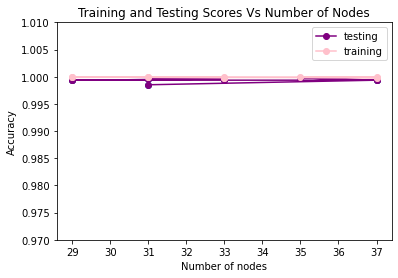

In [80]:
plotGraph(node3, traina, testa)

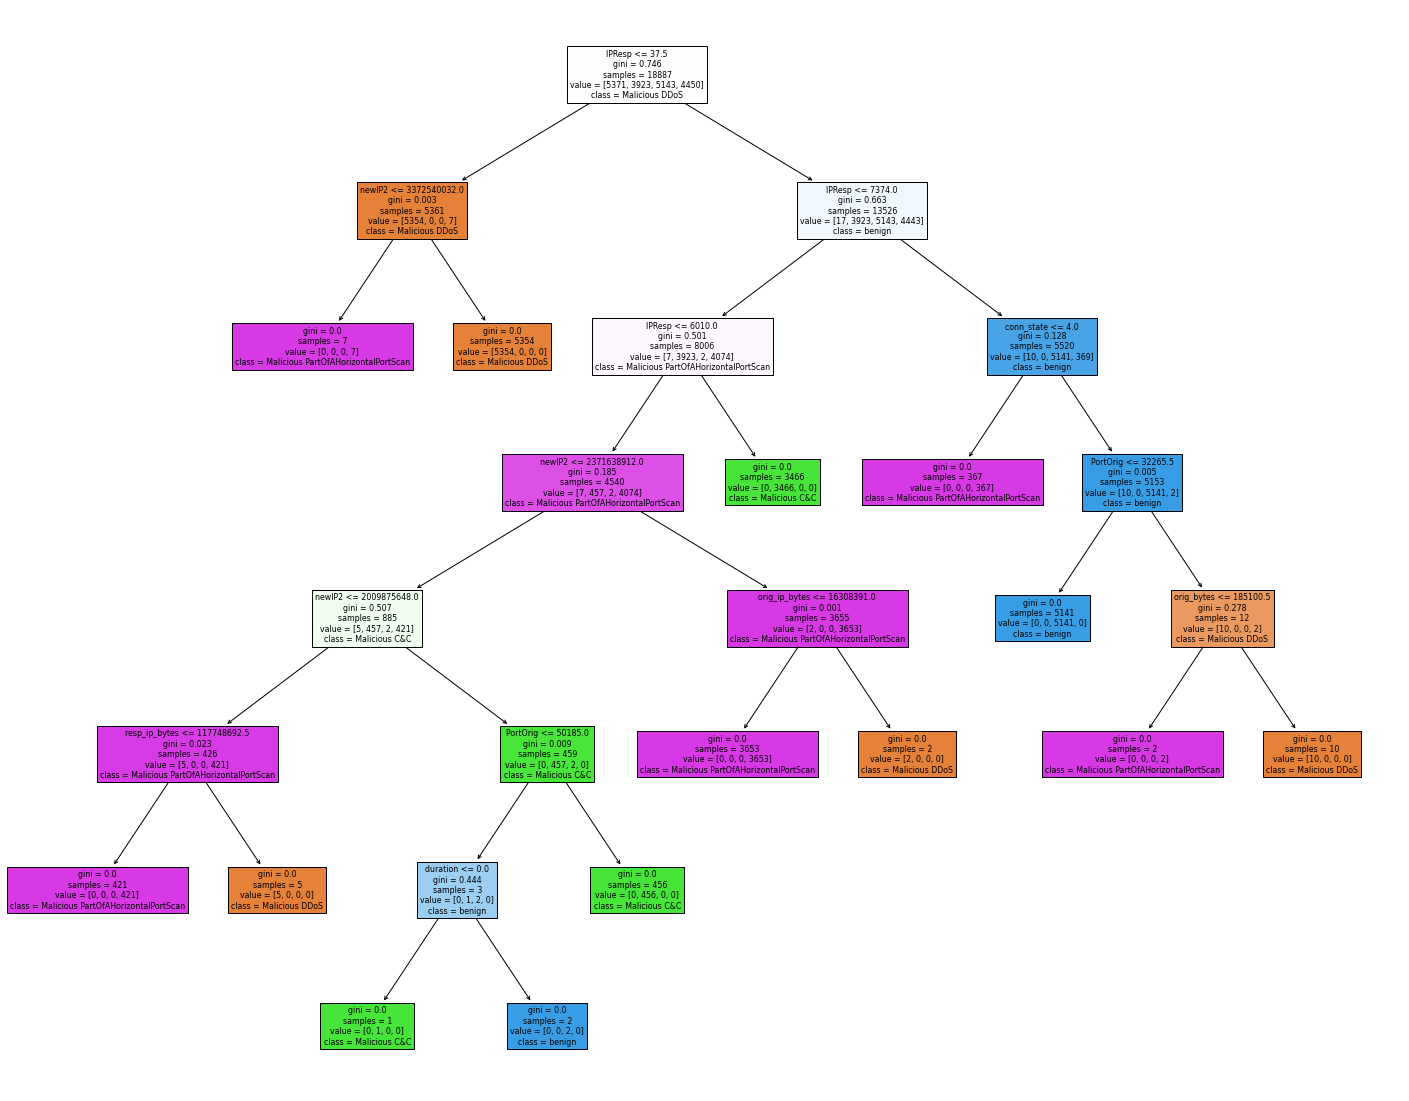

In [ ]:
# Tree Plot for model after hypertunning of parameters 
fig = plt.figure(figsize=(25,20))
_= tree.plot_tree(modelss[4], feature_names=featureCols,  class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan'],
                   filled=True)

<h2>Tuning DT</h2>

In [82]:
def holdoutHP(x, y,clf1, type1):
    sum_training=0
    sum_testing=0
    sum_nodes=0
    clf=[]
    training_accuracy=[]
    testing_accuracy=[]
    nodes=[]
    for i in range(10):
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2) #random split
        #clf1 = tree.DecisionTreeClassifier(random_state=1, max_features=)
        clf1 = clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        u=clf1.tree_
        u.node_count
        print(u.node_count)
        nodes.append(u.node_count)
        sum_nodes+=u.node_count
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    print(np.ceil(sum_nodes/10))
    return training_accuracy, testing_accuracy, nodes, clf

In [83]:
clf1HP = tree.DecisionTreeClassifier(random_state=1, splitter="best", min_samples_split=8)
trainaP, testaHP, node3HP, modelssHP = holdoutHP(x,y,clf1HP,"trees")

training accuracy  1 :  0.9998941070577646
testing accuracy  1 :  0.9997882253282507
29
training accuracy  2 :  0.9998411605866468
testing accuracy  2 :  1.0
33
training accuracy  3 :  0.9998941070577646
testing accuracy  3 :  0.9997882253282507
37
training accuracy  4 :  0.9997882141155292
testing accuracy  4 :  0.9991529013130029
27
training accuracy  5 :  0.9998411605866468
testing accuracy  5 :  1.0
29
training accuracy  6 :  0.9999470535288822
testing accuracy  6 :  0.9991529013130029
29
training accuracy  7 :  0.9998411605866468
testing accuracy  7 :  1.0
29
training accuracy  8 :  0.9998411605866468
testing accuracy  8 :  0.9997882253282507
29
training accuracy  9 :  0.9998411605866468
testing accuracy  9 :  0.9997882253282507
29
training accuracy  10 :  0.9998411605866468
testing accuracy  10 :  0.9997882253282507
39
Average training accuarcy:  0.9998570445279821
Average testing accuarcy:  0.999724692926726
31.0


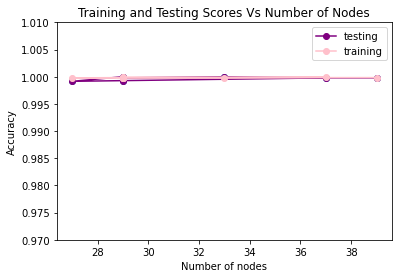

In [84]:
plotGraph(node3HP, trainaP, testaHP)

<h1>Naive Bayes Section </h1>

In [85]:
from random import randint 
from sklearn.metrics import plot_confusion_matrix
#disp = plot_confusion_matrix(grid, x_test, y_test, cmap='Blues', values_format='.3g')
def holdout2(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, shuffle=True, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='.3g')
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred

    #print(classification_report(y_test, y_pred, target_names=class_names))

    #print(confusion_matrix(y_test, y_predict))

training accuracy  1 :  0.7847725949065495
testing accuracy  1 :  0.7814485387547649
training accuracy  2 :  0.7821252713506645
testing accuracy  2 :  0.7920372723422279
training accuracy  3 :  0.7827606290040768
testing accuracy  3 :  0.7892842016094875
training accuracy  4 :  0.783978397839784
testing accuracy  4 :  0.7846251588310038
training accuracy  5 :  0.7911791179117912
testing accuracy  5 :  0.7873782295637441
training accuracy  6 :  0.7848255413776671
testing accuracy  6 :  0.7812367640830157
training accuracy  7 :  0.7839254513686663
testing accuracy  7 :  0.7846251588310038
training accuracy  8 :  0.7911791179117912
testing accuracy  8 :  0.7873782295637441
training accuracy  9 :  0.7934558161698523
testing accuracy  9 :  0.7829309614570097
training accuracy  10 :  0.7856726849155504
testing accuracy  10 :  0.7778483693350275
Average training accuarcy:  0.7863874622756393
Average testing accuarcy:  0.784879288437103


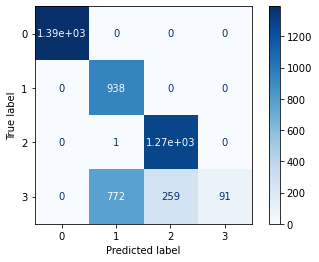

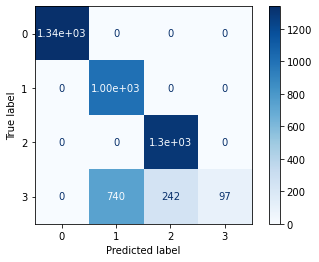

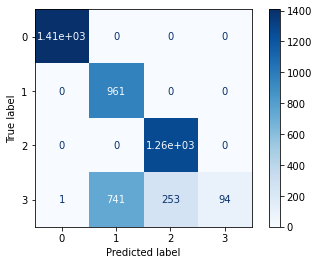

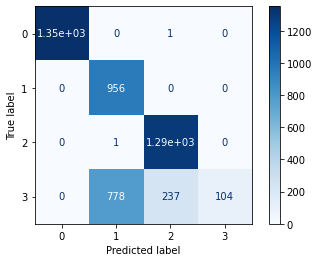

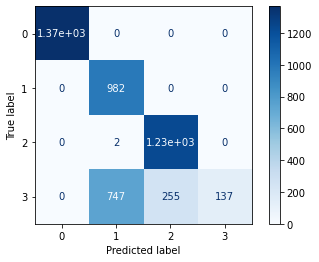

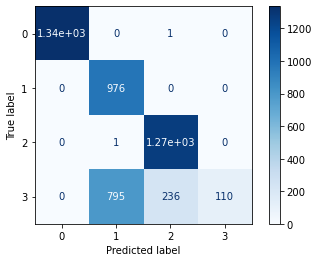

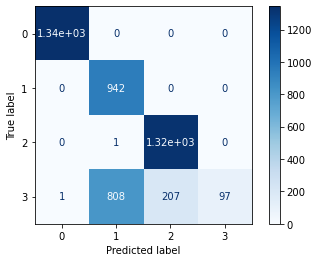

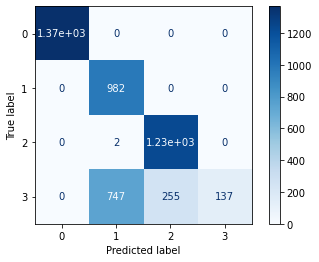

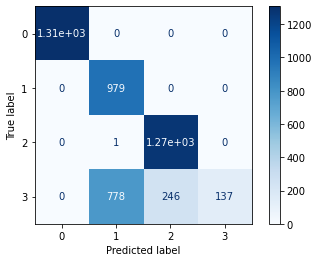

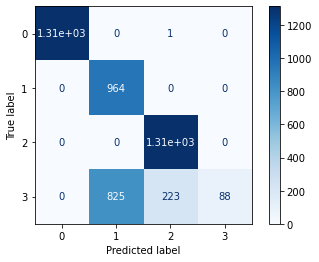

In [86]:
from sklearn.naive_bayes import GaussianNB
modelNV = GaussianNB()

trainNV, testNV, modelNV2, acc, pred = holdout2(x,y, modelNV)

In [87]:
print(acc)

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      1.00      1.00      1309
                      Malicious C&C       0.54      1.00      0.70       964
                             benign       0.85      1.00      0.92      1313
Malicious PartOfAHorizontalPortScan       1.00      0.08      0.14      1136

                           accuracy                           0.78      4722
                          macro avg       0.85      0.77      0.69      4722
                       weighted avg       0.87      0.78      0.71      4722



<h2>Tuning NV</h2>

In [88]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
param_grid_nb = {
    'var_smoothing': np.logspace(0,-9, num=100)
}
x_train2,x_test2,y_train2,y_test2=train_test_split(x,y,test_size=0.2, shuffle=True, random_state=42)
nbModel_grid = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid_nb, verbose=1, cv=10, n_jobs=-1)
nbModel_grid.fit(x_train2, y_train2)
print(nbModel_grid.best_estimator_)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:   15.0s


GaussianNB(var_smoothing=2.848035868435799e-06)


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   18.8s finished


In [89]:
print("Training accurcay ", nbModel_grid.score(x_train2,y_train2))
print("Testing accurcay ", nbModel_grid.score(x_test2,y_test2))

Training accurcay  0.7942500132366178
Testing accurcay  0.7971198644642101


[[1358    0    2    0]
 [   0  987    0    0]
 [   0    0 1270    0]
 [   0  420  536  149]] : is the confusion matrix


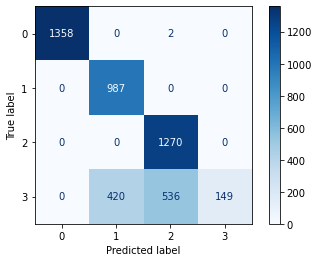

In [90]:
y_pred2 = nbModel_grid.predict(x_test2)
print(plot_confusion_matrix(nbModel_grid, x_test2, y_test2, cmap='Blues', values_format='g'))
print(confusion_matrix(y_test2, y_pred2), ": is the confusion matrix")

In [91]:
class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']

print(classification_report(y_test2, y_pred2, target_names=class_names))

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      1.00      1.00      1360
                      Malicious C&C       0.70      1.00      0.82       987
                             benign       0.70      1.00      0.83      1270
Malicious PartOfAHorizontalPortScan       1.00      0.13      0.24      1105

                           accuracy                           0.80      4722
                          macro avg       0.85      0.78      0.72      4722
                       weighted avg       0.86      0.80      0.74      4722



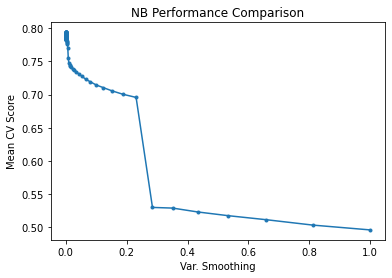

In [92]:


results_NB = pd.DataFrame(nbModel_grid.cv_results_['params'])
results_NB['test_score'] = nbModel_grid.cv_results_['mean_test_score']


plt.plot(results_NB['var_smoothing'], results_NB['test_score'], marker = '.')    
plt.xlabel('Var. Smoothing')
plt.ylabel("Mean CV Score")
plt.title("NB Performance Comparison")
plt.show()



<h1>KNN Section</h1>

In [ ]:
from random import randint 
from sklearn.metrics import plot_confusion_matrix
#disp = plot_confusion_matrix(grid, x_test, y_test, cmap='Blues', values_format='.3g')
def holdout2KNN(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, shuffle=True, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='.3g')
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred

In [ ]:
print(points)
print(train_accuracy)
print(test_accuracy)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0.992587494043522, 0.9926404405146397, 0.9911049928522264, 0.988881241065283, 0.9924286546301689, 0.9893048128342246, 0.9892518663631069, 0.992058029332345, 0.9918462434478742, 0.9917932969767564]
[0.9898348157560356, 0.9938585345192715, 0.9921643371452774, 0.9855993223210504, 0.9940703091910208, 0.9881406183820415, 0.9875052943667937, 0.9904701397712834, 0.9915290131300296, 0.9919525624735281]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1342
           1       1.00      1.00      1.00       975
           2       0.98      1.00      0.99      1275
           3       0.98      0.98      0.98      1130

    accuracy                           0.99      4722
   macro avg       0.99      0.99      0.99      4722
weighted avg       0.99      0.99      0.99      4722



In [ ]:
from sklearn.metrics import confusion_matrix 
confusion_matrix(y_test,y_pred)


array([[1328,    0,    0,   14],
       [   0,  971,    0,    4],
       [   0,    0, 1275,    0],
       [   0,    0,   20, 1110]], dtype=int64)

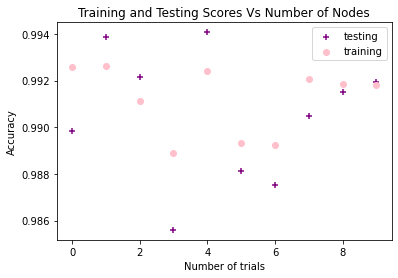

In [ ]:
from matplotlib import pyplot as plt

plt.scatter(points, test_accuracy, color='purple', marker='+', label= 'testing')
plt.scatter(points, train_accuracy, color='pink', marker='o', label = 'training')
plt.xlabel('Number of trials')
plt.ylabel('Accuracy')
plt.title('Training and Testing Scores Vs Number of Nodes')
plt.axis('tight')
leg = plt.legend();
plt.show()

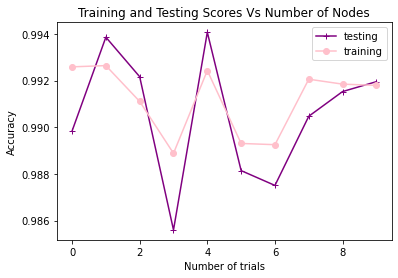

In [ ]:
from matplotlib import pyplot as plt

plt.plot(points, test_accuracy, color='purple', marker='+', label= 'testing')
plt.plot(points, train_accuracy, color='pink', marker='o', label = 'training')
plt.xlabel('Number of trials')
plt.ylabel('Accuracy')
plt.title('Training and Testing Scores Vs Number of Nodes')
plt.axis('tight')
leg = plt.legend();

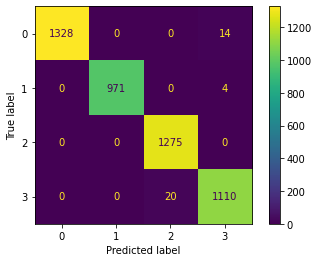

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels= knn.classes_)
disp.plot()


<h2>After tuning</h2>

In [ ]:
#KNN
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
  
def KNN(x,y,n):
    knn= KNeighborsClassifier(n_neighbors = n)
    points=[]
    train_accuracy=[]
    test_accuracy=[]

    for i in range(10):
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
        knn.fit(x_train,y_train)
        y_pred=knn.predict (x_test)
        error_rate.append(np.mean(y_pred != y_test))
        points.append(i)
        train_accuracy.append(knn.score(x_train,y_train))
        test_accuracy.append(knn.score(x_test,y_test))
        print("Train accuracy: ", i+1 ,": ", knn.score(x_train,y_train))
        print("Test accuracy: ", i+1 ,": ", knn.score(x_test,y_test))
        #y_pred

    avg_train_acc_score = sum(train_accuracy)/10
    avg_test_acc_score = sum(test_accuracy)/10
    print('\nAvg Training Accuracy : {}'.format(avg_train_acc_score))
    print('Avg Testing Accuracy : {}'.format(avg_test_acc_score))
    return y_test, y_pred

In [ ]:
Y_test, Y_pred = KNN(x,y,100)

Train accuracy:  1 :  0.9929581193413459
Test accuracy:  1 :  0.9927996611605252
Train accuracy:  2 :  0.9927992799279928
Test accuracy:  2 :  0.9932232105040237
Train accuracy:  3 :  0.9928522263991105
Test accuracy:  3 :  0.9936467598475223
Train accuracy:  4 :  0.9930110658124636
Test accuracy:  4 :  0.9919525624735281
Train accuracy:  5 :  0.9922168687456981
Test accuracy:  5 :  0.9944938585345193
Train accuracy:  6 :  0.9917932969767564
Test accuracy:  6 :  0.9925878864887759
Train accuracy:  7 :  0.9927463334568751
Test accuracy:  7 :  0.9932232105040237
Train accuracy:  8 :  0.992587494043522
Test accuracy:  8 :  0.9932232105040237
Train accuracy:  9 :  0.993116958754699
Test accuracy:  9 :  0.9923761118170267
Train accuracy:  10 :  0.9924816011012866
Test accuracy:  10 :  0.995129182549767

Avg Training Accuracy : 0.9926563244559748
Avg Testing Accuracy : 0.9932655654383737


In [ ]:
print(points)
print(train_accuracy)
print(test_accuracy)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[0.9927992799279928, 0.991899189918992, 0.993116958754699, 0.9933816911102875, 0.993116958754699, 0.9917932969767564, 0.9929581193413459, 0.9919521363901096, 0.9931699052258167, 0.9923757081590512]
[0.9932232105040237, 0.9923761118170267, 0.9925878864887759, 0.9913172384582803, 0.9930114358322745, 0.9927996611605252, 0.9927996611605252, 0.9921643371452774, 0.9921643371452774, 0.9906819144430327]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1372
           1       0.99      0.97      0.98       967
           2       1.00      1.00      1.00      1261
           3       0.97      0.99      0.98      1122

    accuracy                           0.99      4722
   macro avg       0.99      0.99      0.99      4722
weighted avg       0.99      0.99      0.99      4722



In [ ]:
from sklearn.metrics import confusion_matrix 
confusion_matrix(Y_test,Y_pred)

array([[1370,    0,    1,    1],
       [   0,  938,    0,   29],
       [   0,    0, 1261,    0],
       [   0,    7,    0, 1115]], dtype=int64)

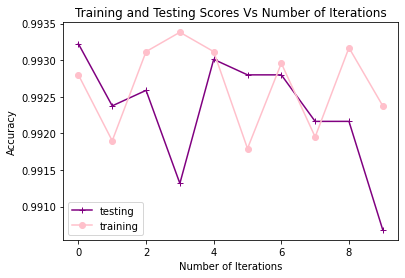

In [ ]:
from matplotlib import pyplot as plt

plt.plot(points, test_accuracy, color='purple', marker='+', label= 'testing')
plt.plot(points, train_accuracy, color='pink', marker='o', label = 'training')
plt.xlabel('Number of Iterations')
plt.ylabel('Accuracy')
plt.title('Training and Testing Scores Vs Number of Iterations')
plt.axis('tight')
leg = plt.legend();

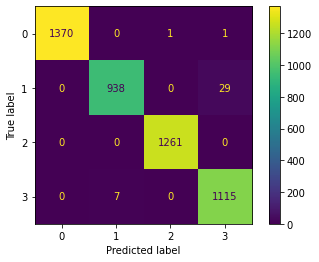

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(Y_test,Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels= knn.classes_)
disp.plot()


# SVM Section  with No Tuning

training accuracy  1 :  0.6007836077725419
testing accuracy  1 :  0.5889453621346887
training accuracy  2 :  0.5996187854079525
testing accuracy  2 :  0.5946632782719187
training accuracy  3 :  0.5940064594694764
testing accuracy  3 :  0.6160525201185938
training accuracy  4 :  0.5971303012654207
testing accuracy  4 :  0.6035578144853876
training accuracy  5 :  0.5972361942076561
testing accuracy  5 :  0.6035578144853876
training accuracy  6 :  0.5975009265632446
testing accuracy  6 :  0.5984752223634053
training accuracy  7 :  0.599724678350188
testing accuracy  7 :  0.5936044049131723
training accuracy  8 :  0.599195213639011
testing accuracy  8 :  0.5961457009741635
training accuracy  9 :  0.599724678350188
testing accuracy  9 :  0.5936044049131723
training accuracy  10 :  0.597765658918833
testing accuracy  10 :  0.602287166454892
Average training accuarcy:  0.5982686503944512
Average testing accuarcy:  0.5990893689114782


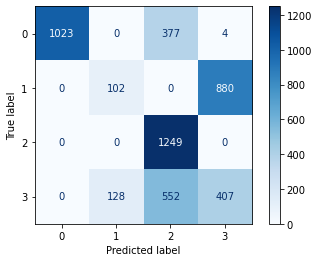

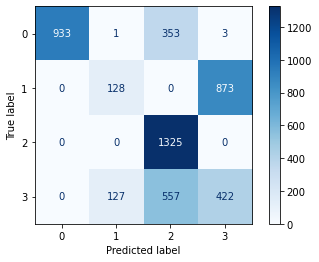

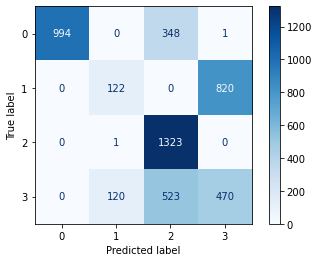

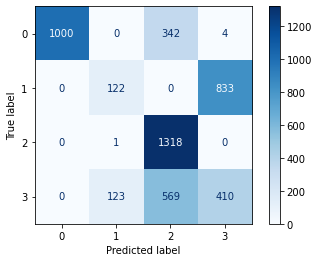

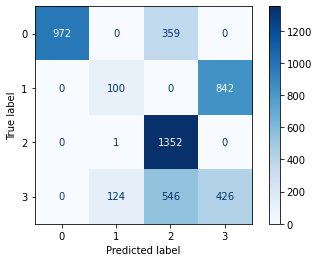

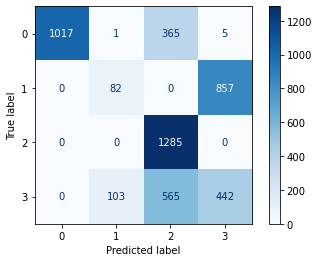

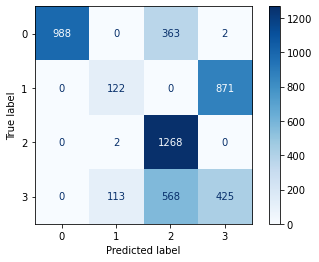

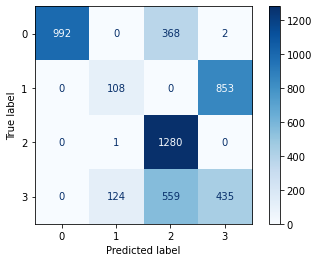

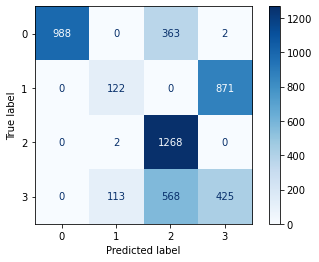

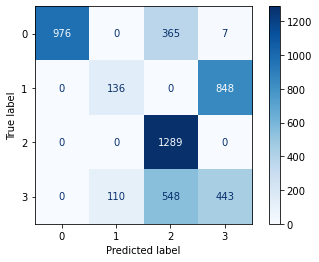

In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
def holdout2(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='g')
    
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred

param_grid={'C':[1],'kernel':['rbf'],'degree':[1]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1)

trainSVM, testSVM, modelSVM, accSVM, predSVM=holdout2(x,y,grid)


In [103]:
print(accSVM)

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      0.72      0.84      1348
                      Malicious C&C       0.55      0.14      0.22       984
                             benign       0.59      1.00      0.74      1289
Malicious PartOfAHorizontalPortScan       0.34      0.40      0.37      1101

                           accuracy                           0.60      4722
                          macro avg       0.62      0.57      0.54      4722
                       weighted avg       0.64      0.60      0.57      4722



training accuracy  1 :  0.3565415365065918
testing accuracy  1 :  0.3598051673019907
training accuracy  2 :  0.34076348811351725
testing accuracy  2 :  0.34858110969927997
training accuracy  3 :  0.30878381955842643
testing accuracy  3 :  0.31300296484540446
training accuracy  4 :  0.33123312331233123
testing accuracy  4 :  0.33079203727234224
training accuracy  5 :  0.19436649547307672
testing accuracy  5 :  0.19758576874205844
training accuracy  6 :  0.31275480489225393
testing accuracy  6 :  0.30199068191444306
training accuracy  7 :  0.27553343569651084
testing accuracy  7 :  0.2683185091063109
training accuracy  8 :  0.2829459416529888
testing accuracy  8 :  0.28017789072426935
training accuracy  9 :  0.23068777465981893
testing accuracy  9 :  0.22596357475645912
training accuracy  10 :  0.3546354635463546
testing accuracy  10 :  0.35429902583650996
Average training accuarcy:  0.2988245883411871
Average testing accuarcy:  0.29805167301990687


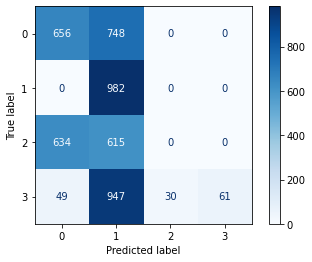

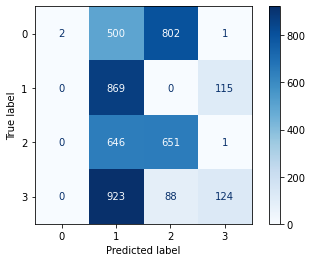

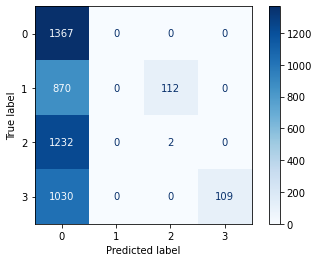

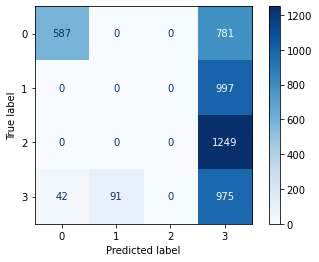

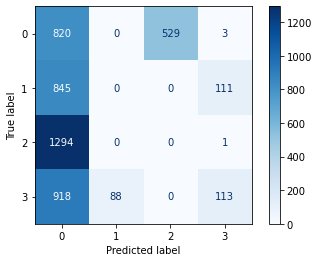

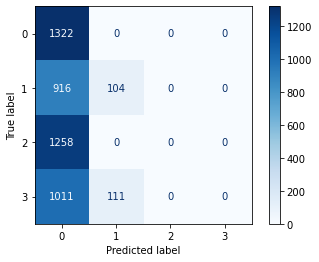

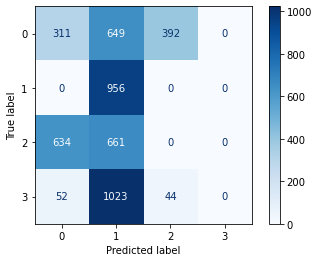

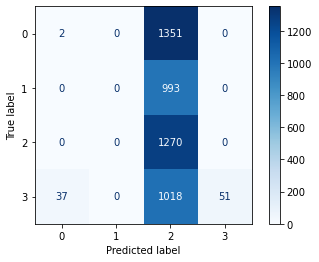

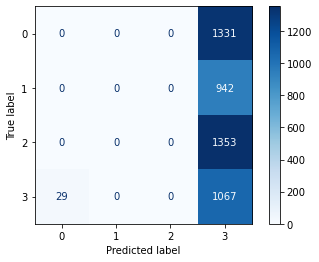

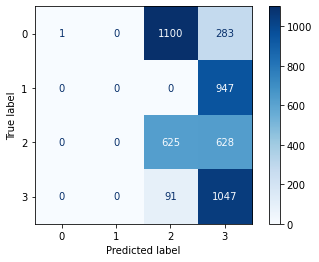

In [106]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')
def holdout2(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='g')
    
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred


grid=LinearSVC()

trainLinearSVM, testLinearSVM, modelLinearSVM, accLinearSVM, predLinearSVM=holdout2(x,y,grid)


In [107]:
print(accLinearSVM)

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      0.00      0.00      1384
                      Malicious C&C       0.00      0.00      0.00       947
                             benign       0.34      0.50      0.41      1253
Malicious PartOfAHorizontalPortScan       0.36      0.92      0.52      1138

                           accuracy                           0.35      4722
                          macro avg       0.43      0.35      0.23      4722
                       weighted avg       0.47      0.35      0.23      4722



# SVM With Tuning

In [ ]:


from sklearn.model_selection import GridSearchCV
import math
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=32)
param_grid={'C':[0.1,1,10,100,1000],'kernel':['rbf'],'degree':[1,2,3,4,5,6,7,10,20,30],'gamma':[1,2,3,4,5,10,20]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1,verbose=2)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 350 candidates, totalling 1750 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  8.0min
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed: 19.2min
[Parallel(n_jobs=-1)]: Done 624 tasks      | elapsed: 36.6min
[Parallel(n_jobs=-1)]: Done 989 tasks      | elapsed: 62.2min
[Parallel(n_jobs=-1)]: Done 1434 tasks      | elapsed: 94.4min
[Parallel(n_jobs=-1)]: Done 1750 out of 1750 | elapsed: 116.9min finished


GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'degree': [1, 2, 3, 4, 5, 6, 7, 10, 20, 30],
                         'gamma': [1, 2, 3, 4, 5, 10, 20], 'kernel': ['rbf']},
             verbose=2)

In [ ]:
grid.best_params_


{'C': 10, 'degree': 1, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:

from sklearn.model_selection import GridSearchCV
import math
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=32)
param_grid={'C':[10],'kernel':['rbf'],'degree':[1]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1)
grid.fit(x_train,y_train)
print(grid.score(x_test,y_test))

0.8386277001270648


In [ ]:
#Finding the best parameters for sigmoid
param_grid={'C':[0.1,1,10],'kernel':['sigmoid']}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1,verbose=2)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:  1.0min remaining:   53.1s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  1.3min finished


GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'kernel': ['sigmoid']}, verbose=2)

In [ ]:
grid.best_params_

{'C': 0.1, 'degree': 1, 'gamma': 1, 'kernel': 'sigmoid'}

In [ ]:
#after finding the best parameters we will take the C and degree but will ignore the gamma to be set automatically
param_grid={'C':[0.1],'kernel':['sigmoid'],'degree':[1]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1,verbose=2)
grid.fit(x_train,y_train)
print(grid.score(x_test,y_test))

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   15.0s remaining:    9.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.1s finished


0.2071156289707751


In [ ]:
param_grid={'C':[1],'kernel':['poly'],'degree':[1]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1)
grid.fit(x_train,y_train)
print(grid.score(x_test,y_test))

0.6188055908513341


{'SVC__C': 80.01}
training accuracy  1 :  0.9959760681950548
testing accuracy  1 :  0.9963998305802626
training accuracy  2 :  0.987292846931752
testing accuracy  2 :  0.9862346463362982
training accuracy  3 :  0.9934875840525229
testing accuracy  3 :  0.993434985175773
training accuracy  4 :  0.9804627521575687
testing accuracy  4 :  0.9752223634053367
training accuracy  5 :  0.9888282945941653
testing accuracy  5 :  0.9889877170690385
training accuracy  6 :  0.9868163286916927
testing accuracy  6 :  0.9858110969927997
training accuracy  7 :  0.9895165987186954
testing accuracy  7 :  0.9896230410842863
training accuracy  8 :  0.9950759781860539
testing accuracy  8 :  0.9930114358322745
training accuracy  9 :  0.9852808810292794
testing accuracy  9 :  0.9858110969927997
training accuracy  10 :  0.996134907608408
testing accuracy  10 :  0.9957645065650148
Average training accuarcy:  0.9898872240165193
Average testing accuarcy:  0.9890300720033884


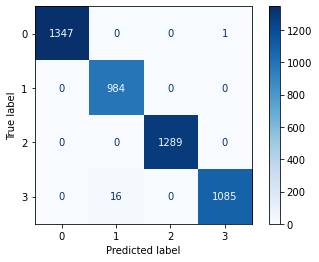

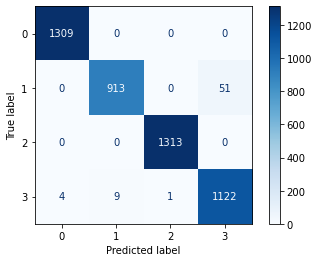

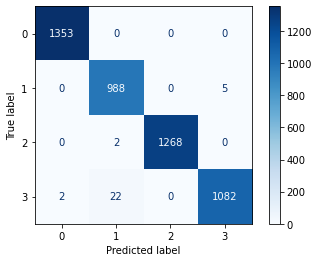

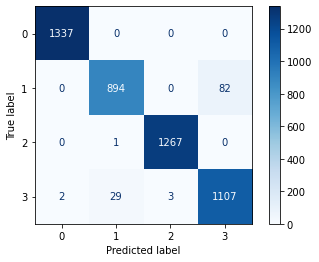

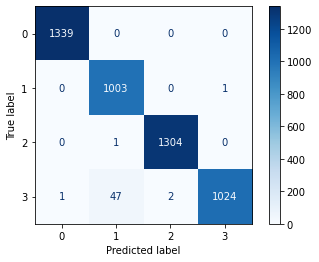

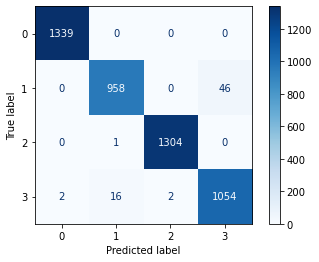

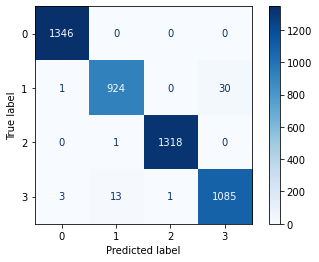

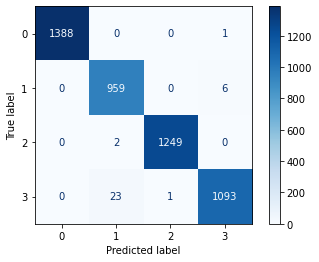

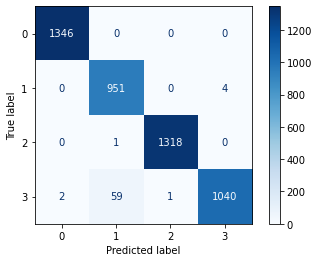

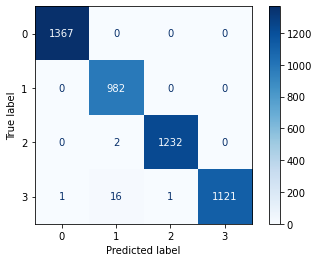

In [109]:
#Linear Search

def holdout2LinearSVC(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        clf1.coef_ = bestlinearSVC.named_steps['SVC'].coef_
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='g')
    
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred





from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
SVCpipe = Pipeline([('scale', StandardScaler()),
                   ('SVC',LinearSVC())])

# Gridsearch to determine the value of C
param_grid = {'SVC__C':np.arange(0.01,100,10)}
linearSVC = GridSearchCV(SVCpipe,param_grid,cv=5,return_train_score=True)
linearSVC.fit(x_train,y_train)
print(linearSVC.best_params_)
#linearSVC.coef_
#linearSVC.intercept_

bestlinearSVC = linearSVC.best_estimator_


trainTunedLinearSVM, testTunedLinearSVM, modelTunedLinearSVM, accTunedLinearSVM, predTunedLinearSVM=holdout2(x,y,bestlinearSVC)

In [110]:
print(accTunedLinearSVM)

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      1.00      1.00      1367
                      Malicious C&C       0.98      1.00      0.99       982
                             benign       1.00      1.00      1.00      1234
Malicious PartOfAHorizontalPortScan       1.00      0.98      0.99      1139

                           accuracy                           1.00      4722
                          macro avg       1.00      1.00      1.00      4722
                       weighted avg       1.00      1.00      1.00      4722



training accuracy  1 :  0.8373493975903614
testing accuracy  1 :  0.8382041507835662
training accuracy  2 :  0.8373964608433735
testing accuracy  2 :  0.8403218975010589
training accuracy  3 :  0.8395613704819277
testing accuracy  3 :  0.819144430326133
training accuracy  4 :  0.8374905873493976
testing accuracy  4 :  0.8382041507835662
training accuracy  5 :  0.8382435993975904
testing accuracy  5 :  0.8326980093180856
training accuracy  6 :  0.8377259036144579
testing accuracy  6 :  0.8352393053790766
training accuracy  7 :  0.8374905873493976
testing accuracy  7 :  0.8382041507835662
training accuracy  8 :  0.8364551957831325
testing accuracy  8 :  0.8475222363405337
training accuracy  9 :  0.8366434487951807
testing accuracy  9 :  0.8441338415925456
training accuracy  10 :  0.8375847138554217
testing accuracy  10 :  0.8369335027530708
Average training accuarcy:  0.8375941265060242
Average testing accuarcy:  0.8370605675561202


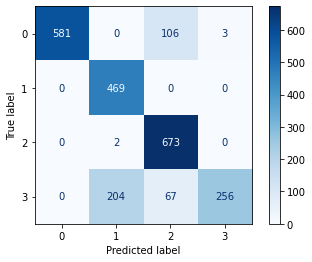

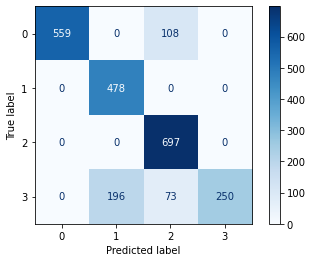

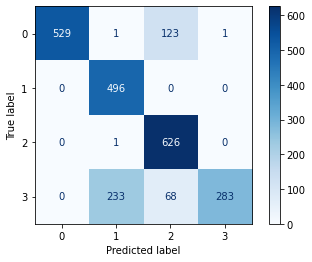

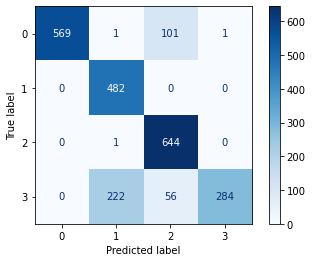

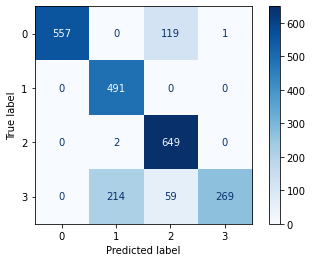

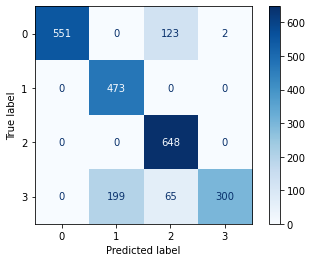

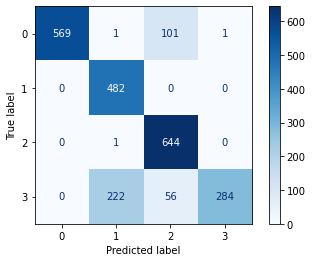

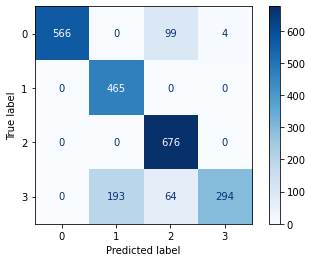

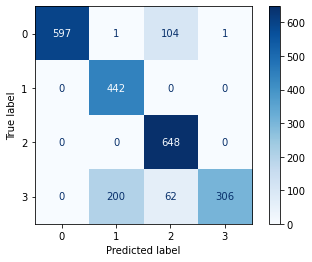

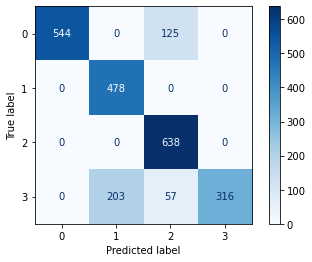

In [112]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
def holdout2(x, y, clf1):
    sum_training=0
    sum_testing=0
    #clf=[]
    acc = 0 
    pred = 0
    training_accuracy=[]
    class_names=['Malicious DDoS','Malicious C&C','benign','Malicious PartOfAHorizontalPortScan']
    testing_accuracy=[]
    for i in range(10):
        j = randint(10,50)
        x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1, random_state=j) #random split
        #clf1 = GaussianNB()
        clf1.fit(x_train,y_train)
        y_pred=clf1.predict(x_test)
        m = clf1.score(x_train,y_train)
        p = clf1.score(x_test,y_test)
        training_accuracy.append(m)
        testing_accuracy.append(p)
        print("training accuracy " , i+1 ,": ", m)
        print("testing accuracy " , i+1 , ": ", p)
        sum_training+=clf1.score(x_train,y_train)
        sum_testing+=clf1.score(x_test,y_test)
        clf.append(clf1)        
        acc = classification_report(y_test, y_pred, target_names=class_names)
        pred = plot_confusion_matrix(clf1, x_test, y_test, cmap='Blues', values_format='g')
    
    print("Average training accuarcy: ", sum_training/10)
    print("Average testing accuarcy: ",sum_testing/10)
    return training_accuracy, testing_accuracy, clf1, acc, pred
import warnings
warnings.filterwarnings('ignore')
param_grid={'C':[10],'kernel':['rbf'],'degree':[1]}
grid=GridSearchCV(SVC(),param_grid,n_jobs=-1)

trainSVM, testSVM, modelSVM, accSVM, predSVM=holdout2(x,y,grid)

In [113]:
print(accSVM)

                                     precision    recall  f1-score   support

                     Malicious DDoS       1.00      0.81      0.90       669
                      Malicious C&C       0.70      1.00      0.82       478
                             benign       0.78      1.00      0.88       638
Malicious PartOfAHorizontalPortScan       1.00      0.55      0.71       576

                           accuracy                           0.84      2361
                          macro avg       0.87      0.84      0.83      2361
                       weighted avg       0.88      0.84      0.83      2361

